In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
from torch.nn import BCEWithLogitsLoss
from torchvision import models
import torch.nn as nn
import cv2

In [2]:
# initializing the test data

df=pd.read_csv('/kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv')
disease_labels = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

for disease in disease_labels:
    df[disease]=df['Finding Labels'].apply(lambda x:1 if disease in x.split('|') else 0)

with open('/kaggle/input/datasets/nih-chest-xrays/data/train_val_list.txt') as f:
    train_val_list = [line.strip() for line in f.readlines()]
with open('/kaggle/input/datasets/nih-chest-xrays/data/test_list.txt') as f:
    test_list = [line.strip() for line in f.readlines()]

#df split
train_val_df = df[df['Image Index'].isin(train_val_list)]
test_df = df[df['Image Index'].isin(test_list)]

image_dirs = []
for dirname, subdirs, filenames in os.walk('/kaggle/input/datasets/nih-chest-xrays'):
    if any(f.endswith('.png') for f in filenames):
        image_dirs.append(dirname)

# image lookup
image_path_dict = {}
for image_dir in image_dirs:
    for filename in os.listdir(image_dir):
        if filename.endswith('.png'):
            image_path_dict[filename] = os.path.join(image_dir, filename)

class ChestXrayDataset(Dataset):
    def __init__(self, df, image_path_dict, disease_labels, transform):
        self.df=df.reset_index(drop=True)
        self.image_path_dict=image_path_dict
        self.disease_labels=disease_labels
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row=self.df.iloc[idx]

        img_path=self.image_path_dict[row['Image Index']]
        img=Image.open(img_path).convert('RGB')

        if self.transform:
            img=self.transform(img)

        labels=torch.tensor(row[self.disease_labels].values.astype(float),
                           dtype=torch.float32)

        return img, labels

val_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
test_dataset = ChestXrayDataset(test_df, image_path_dict, disease_labels, val_transform)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=models.densenet121(weights=None)
num_features=model.classifier.in_features
model.classifier=nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 14)
)
model.load_state_dict(
    torch.load('/kaggle/input/models/adyanmukadam/chest-x-ray-densenet/pytorch/default/1/best_densenet_nih.pth',
              map_location=device)
)
model.to(device)
model.eval();

In [4]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model=model
        self.activations=None
        self.gradients=None
        target_layer.register_forward_hook(
            self.save_activation
        )
        target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations=output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients=grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        output=self.model(input_tensor)
        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = torch.relu(cam)
        cam = (cam-cam.min())/(cam.max()+1e-8)

        return cam.squeeze().cpu().numpy()

In [5]:
target_layer=model.features.denseblock4

In [6]:
gradcam=GradCAM(model, target_layer)

In [7]:
cardio_idx=disease_labels.index('Cardiomegaly')
best_prob=-1
best_image=None
best_label=None

for images, labels in test_loader:
    images=images.to(device)
    with torch.no_grad():
        probs=torch.sigmoid(model(images))

    for i in range(len(images)):
        if labels[i, cardio_idx]==1:
            prob=probs[i, cardio_idx].item()
            if prob>best_prob:
                best_prob=prob
                best_image=images[i].unsqueeze(0).cpu()
                best_label=labels[i]

print("Best probability:", best_prob)

Best probability: 0.7262696027755737


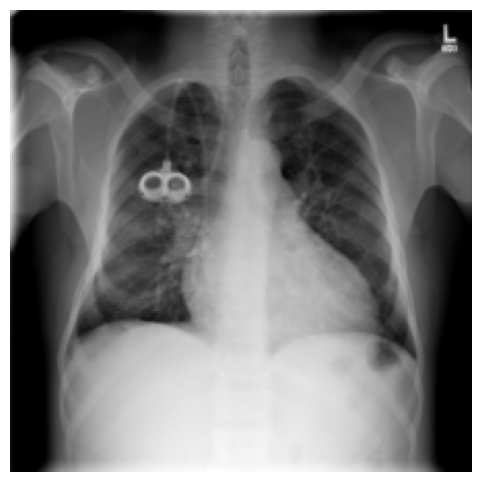

In [8]:
img = best_image.squeeze().cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(img[0], cmap='gray')
plt.axis('off')
plt.show()

In [9]:
cam=gradcam.generate(best_image.to(device), cardio_idx)
cam_resized=cv2.resize(cam, (224,224))

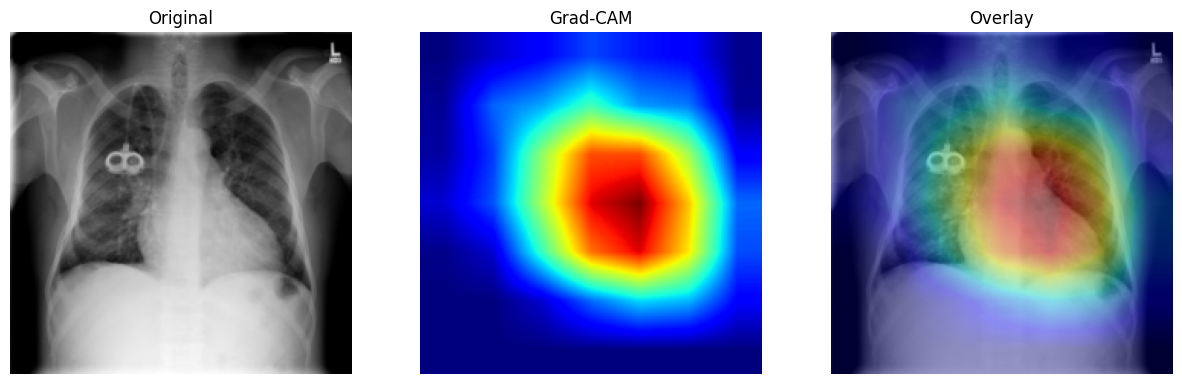

In [10]:
img = best_image.squeeze().cpu().numpy()[0]

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(132)
plt.imshow(cam_resized, cmap='jet')
plt.title("Grad-CAM")
plt.axis('off')

plt.subplot(133)
plt.imshow(img, cmap='gray')
plt.imshow(cam_resized, cmap='jet', alpha=0.4)
plt.title("Overlay")
plt.axis('off')

plt.show()

In [ ]:
cardiomegaly_idx = disease_labels.index('Cardiomegaly')

fp_record = None  
fn_record = None

for images, labels in test_loader:
    images_dev = images.to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(images_dev)).cpu()
    
    for b in range(images.size(0)):
        gt = labels[b, cardiomegaly_idx].item()
        prob = probs[b, cardiomegaly_idx].item()
        
        # Capture False Positive (Highest probability among false alarms)
        if gt == 0 and prob >= 0.50:
            if fp_record is None or prob > fp_record['prob']:
                fp_record = {'image': images[b].unsqueeze(0), 'prob': prob, 'gt': gt}
                
        # Capture False Negative (Lowest probability among missed cases)
        if gt == 1 and prob < 0.20:
            if fn_record is None or prob < fn_record['prob']:
                fn_record = {'image': images[b].unsqueeze(0), 'prob': prob, 'gt': gt}
                
    if fp_record is not None and fn_record is not None:
        pass

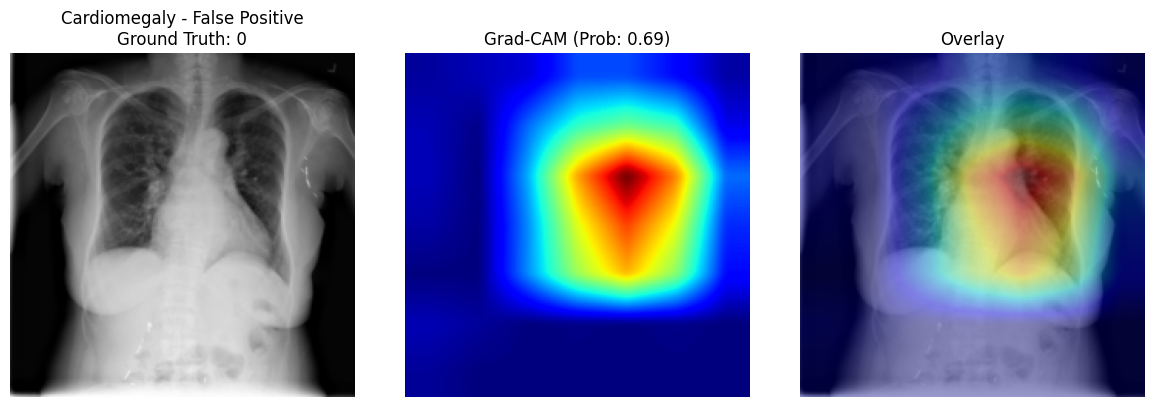

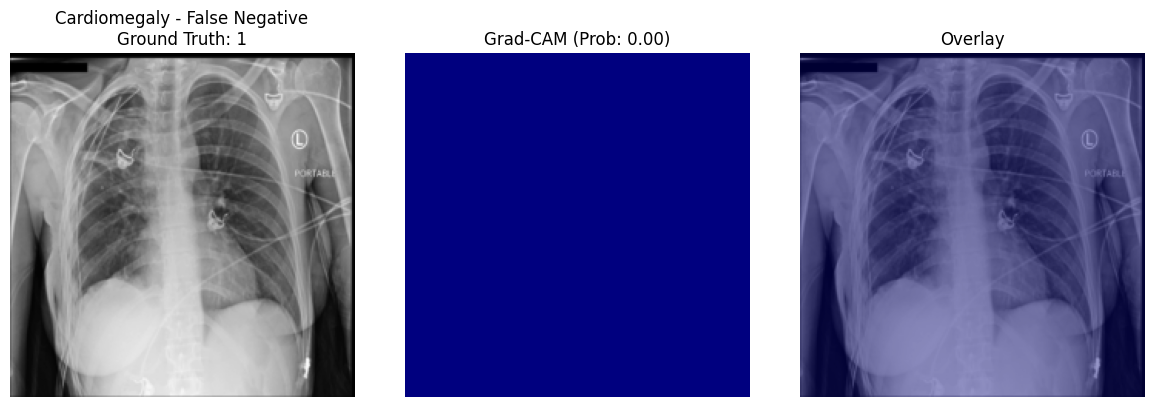

In [24]:
output_dir = "gradcam_visualizations"
os.makedirs(output_dir, exist_ok=True)

def plot_error_gradcam(record, title_prefix, filename):
    img_tensor = record['image'].to(device)
    cam = gradcam.generate(img_tensor, cardiomegaly_idx)
    cam_resized = cv2.resize(cam, (224, 224))
    cam_blurred = cv2.GaussianBlur(cam_resized, (11, 11), 0)
    
    raw_img = record['image'].squeeze().cpu().numpy()[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(raw_img, cmap='gray')
    axes[0].set_title(f"{title_prefix}\nGround Truth: {int(record['gt'])}")
    axes[0].axis('off')
    
    axes[1].imshow(cam_blurred, cmap='jet')
    axes[1].set_title(f"Grad-CAM (Prob: {record['prob']:.2f})")
    axes[1].axis('off')
    
    axes[2].imshow(raw_img, cmap='gray')
    axes[2].imshow(cam_blurred, cmap='jet', alpha=0.4)
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    
    plt.tight_layout()
    file_path = os.path.join(output_dir, filename)
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

if fp_record:
    plot_error_gradcam(fp_record, "Cardiomegaly - False Positive", "Cardiomegaly_FP_gradcam.png")
else:
    print("No False Positive sample found meeting criteria.")

if fn_record:
    plot_error_gradcam(fn_record, "Cardiomegaly - False Negative", "Cardiomegaly_FN_gradcam.png")
else:
    print("No False Negative sample found meeting criteria.")

In [11]:
# Find the top-scoring image per disease across the test set
disease_best_records = {disease: {'prob': -1.0, 'image': None} for disease in disease_labels}

for images, labels in test_loader:
    images = images.to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(images)).cpu()
    
    for i, disease in enumerate(disease_labels):
        max_val, max_idx = torch.max(probs[:, i], dim=0)
        if max_val.item() > disease_best_records[disease]['prob']:
            disease_best_records[disease]['prob'] = max_val.item()
            disease_best_records[disease]['image'] = images[max_idx].unsqueeze(0)

for disease, record in disease_best_records.items():
    print(f"{disease:20s} -> Best Prob: {record['prob']:.4f}")

Atelectasis          -> Best Prob: 0.6673
Cardiomegaly         -> Best Prob: 0.7263
Consolidation        -> Best Prob: 0.2843
Edema                -> Best Prob: 0.4180
Effusion             -> Best Prob: 0.8899
Emphysema            -> Best Prob: 0.8648
Fibrosis             -> Best Prob: 0.2024
Hernia               -> Best Prob: 0.0543
Infiltration         -> Best Prob: 0.6884
Mass                 -> Best Prob: 0.7175
Nodule               -> Best Prob: 0.5225
Pleural_Thickening   -> Best Prob: 0.2586
Pneumonia            -> Best Prob: 0.1253
Pneumothorax         -> Best Prob: 0.6615


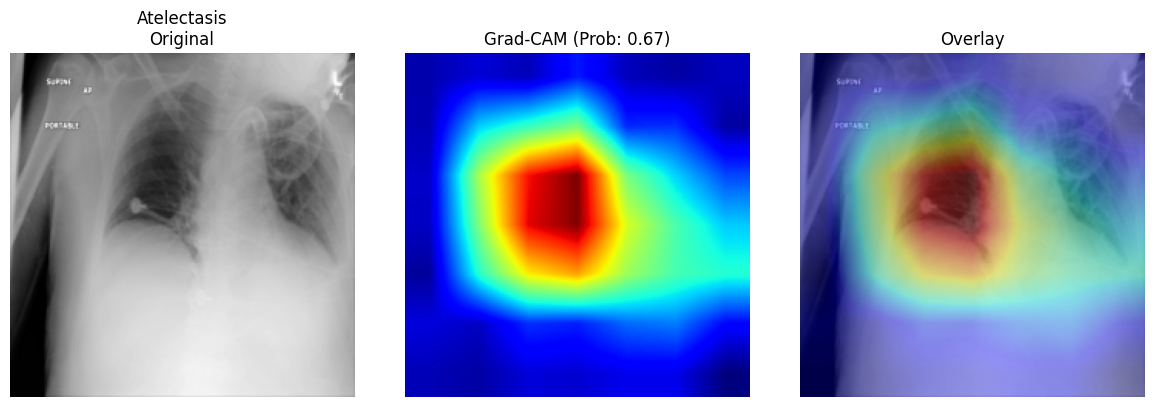

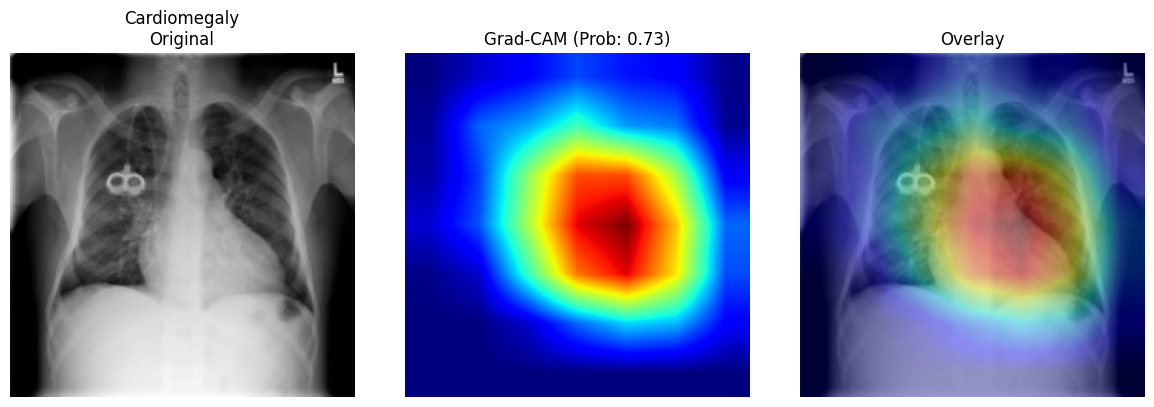

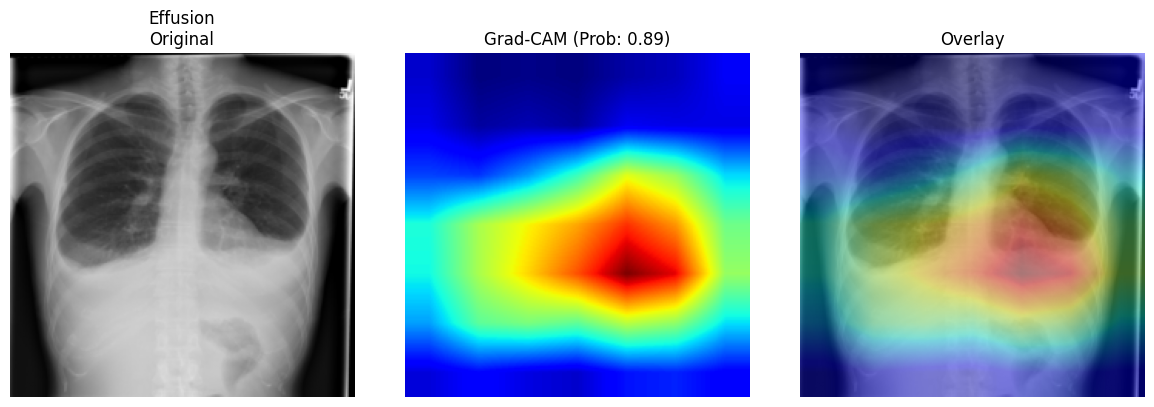

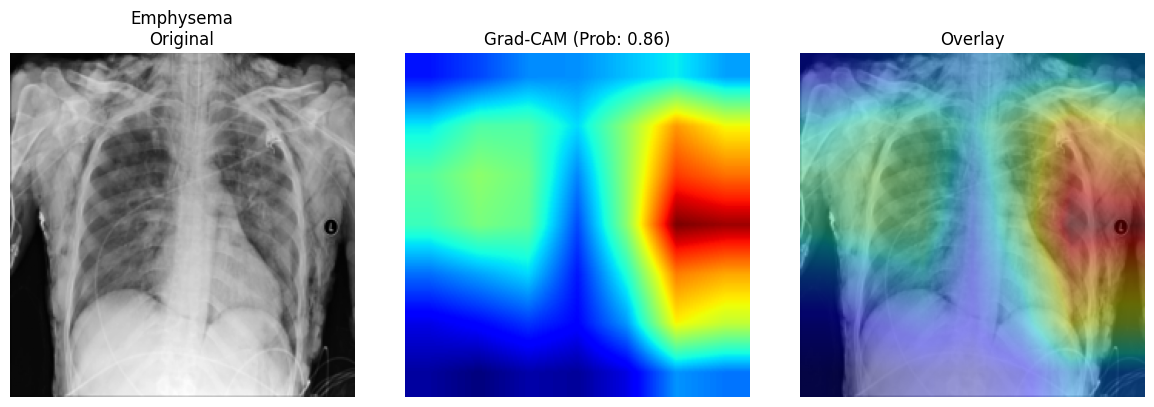

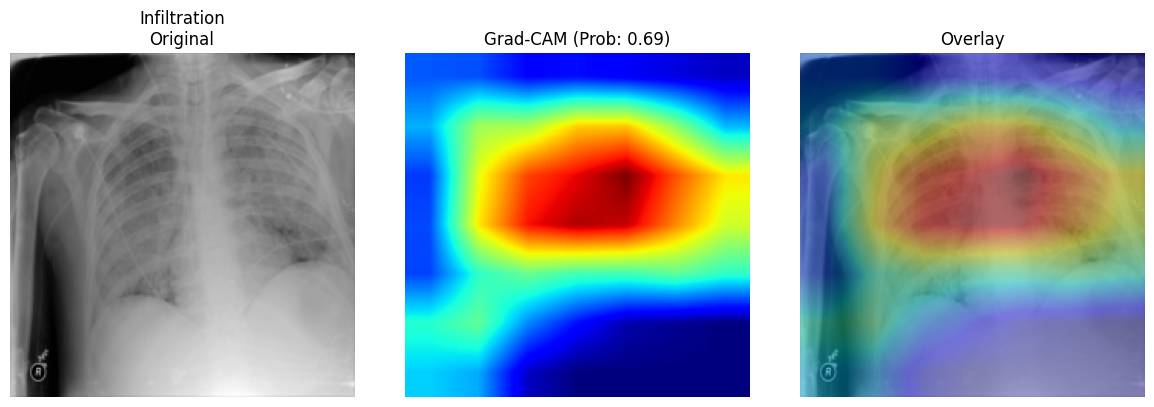

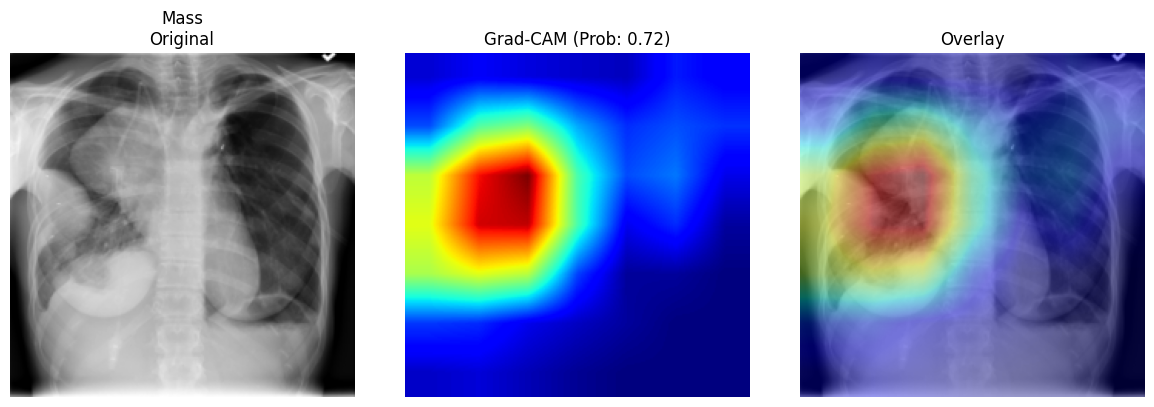

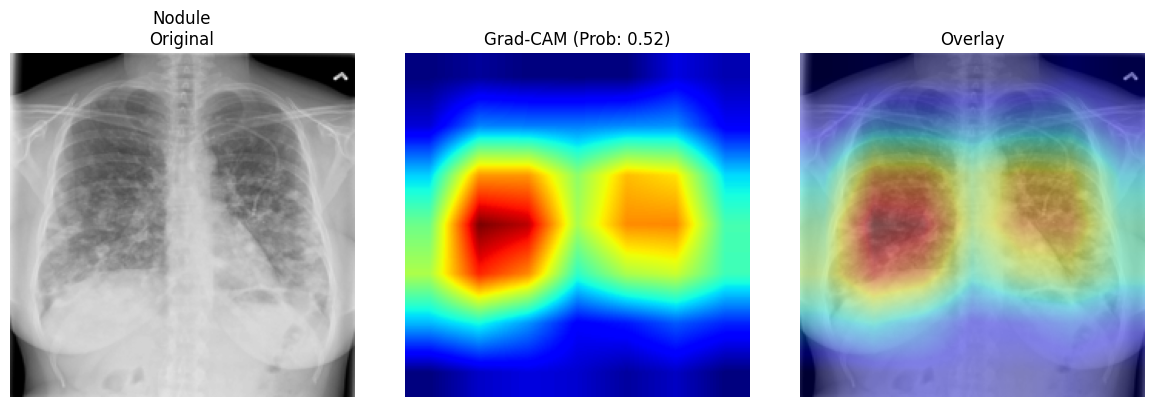

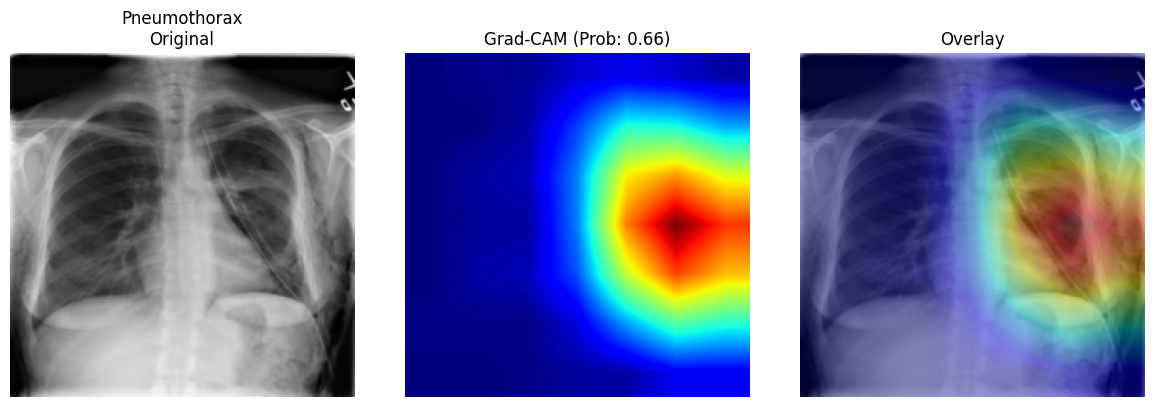

In [21]:
# Generate and plot Grad-CAM overlay for high-confidence diseases
output_dir= 'gradcam_visualisations'
os.makedirs(output_dir, exist_ok=True)

PROB_THRESHOLD = 0.5  

for disease, record in disease_best_records.items():
    if record['prob'] < PROB_THRESHOLD or record['image'] is None:
        continue
        
    disease_idx = disease_labels.index(disease)
    img_tensor = record['image'].to(device)
    
    cam = gradcam.generate(img_tensor, disease_idx)
    cam_resized = cv2.resize(cam, (224, 224))
    
    raw_img = record['image'].squeeze().cpu().numpy()[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(raw_img, cmap='gray')
    axes[0].set_title(f"{disease}\nOriginal")
    axes[0].axis('off')
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title(f"Grad-CAM (Prob: {record['prob']:.2f})")
    axes[1].axis('off')
    
    axes[2].imshow(raw_img, cmap='gray')
    axes[2].imshow(cam_resized, cmap='jet', alpha=0.4)
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    
    plt.tight_layout()
    file_path = os.path.join(output_dir, f"{disease}_gradcam.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

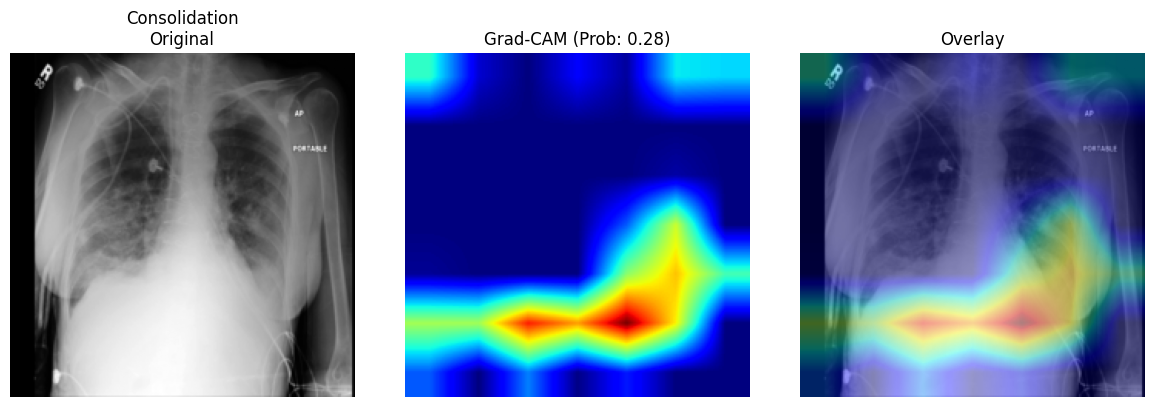

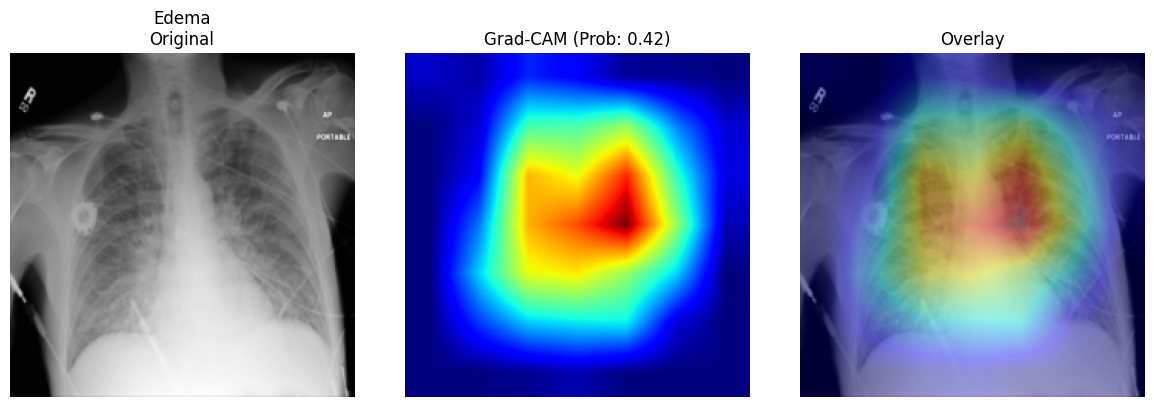

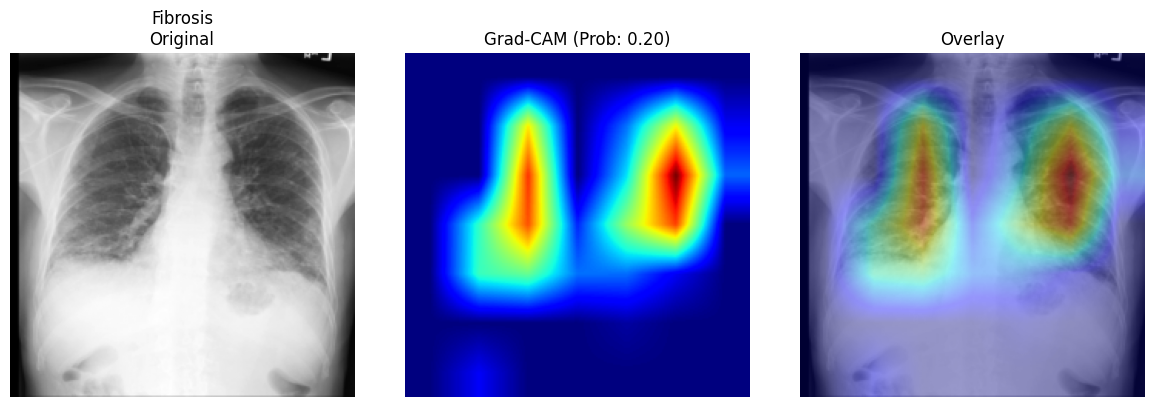

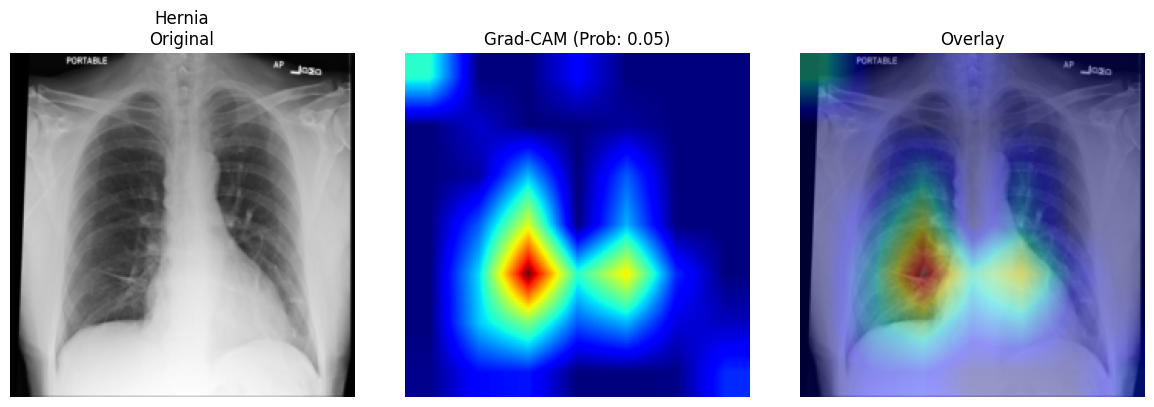

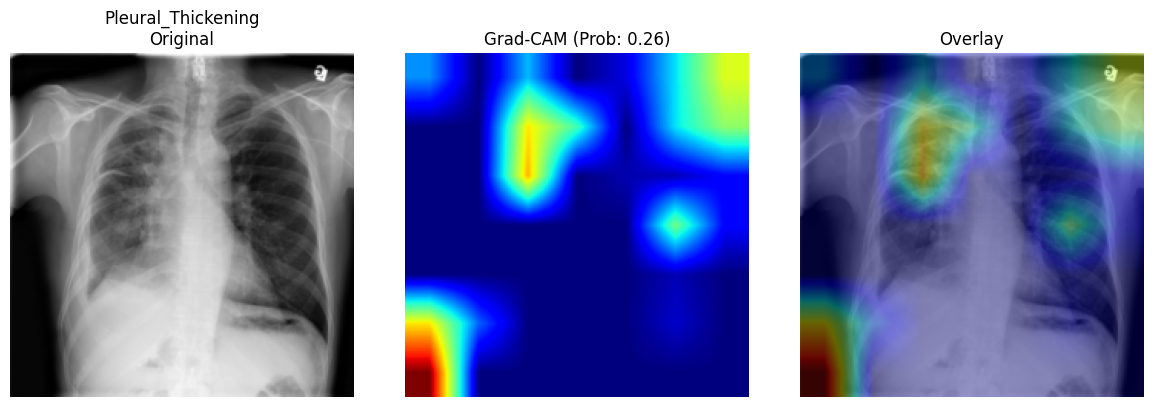

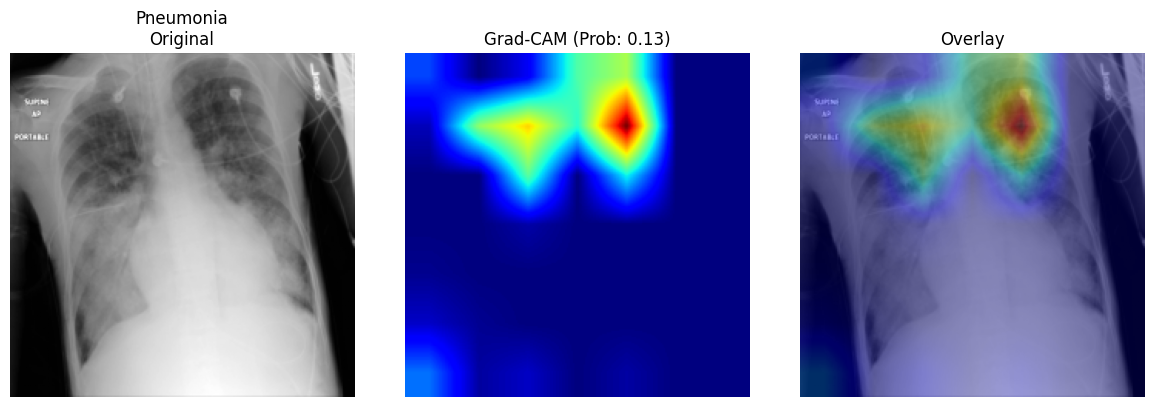

In [23]:
# Generate and plot Grad-CAM overlay for low-confidence diseases
PROB_THRESHOLD = 0.5  

for disease, record in disease_best_records.items():
    if record['prob'] > PROB_THRESHOLD or record['image'] is None:
        continue
        
    disease_idx = disease_labels.index(disease)
    img_tensor = record['image'].to(device)
    
    cam = gradcam.generate(img_tensor, disease_idx)
    cam_resized = cv2.resize(cam, (224, 224))
    
    raw_img = record['image'].squeeze().cpu().numpy()[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(raw_img, cmap='gray')
    axes[0].set_title(f"{disease}\nOriginal")
    axes[0].axis('off')
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title(f"Grad-CAM (Prob: {record['prob']:.2f})")
    axes[1].axis('off')
    
    axes[2].imshow(raw_img, cmap='gray')
    axes[2].imshow(cam_resized, cmap='jet', alpha=0.4)
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    
    plt.tight_layout()
    file_path = os.path.join(output_dir, f"{disease}_gradcam.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()